## 0) Install dependencies
Run Cell 1 once per environment to install all required packages from requirements.txt.

In [ ]:
from pathlib import Path

req_file = (Path.cwd() / "requirements.txt").resolve()
if not req_file.exists():
    raise FileNotFoundError(f"requirements.txt not found at: {req_file}")

print(f"Installing dependencies from: {req_file}")
%pip install -r "{req_file}"
print("Done. If prompted, restart the kernel once.")

# Step 1: Dataset and DataLoader Setup
Notebook-first workflow for Devanagari numeral preprocessing and DataLoaders.

This notebook uses helper methods from the dataloader module and keeps all interaction here.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from dataloader.dataset_utils import build_dataloaders, print_summary, show_one_batch

### Choose the dataset setup values.
Set the train/validation split and loader settings before building the data pipeline.

In [ ]:
# User choices from Step 1
PROJECT_ROOT = Path.cwd().resolve()
TRAIN_DIR = (PROJECT_ROOT / "dataset" / "train").resolve()
TEST_DIR = (PROJECT_ROOT / "dataset" / "test").resolve()
VAL_RATIO = 0.15
BATCH_SIZE = 64
SEED = 42
NUM_WORKERS = 0

print(f"Using train dir: {TRAIN_DIR}")
print(f"Using test dir:  {TEST_DIR}")

### Toggle preprocessing options.
Use these switches to turn the Otsu crop, rotation, and affine augmentation on or off.

In [ ]:
# Notebook-level preprocessing switches
USE_OTSU_CROP_RESIZE = True
USE_TRAIN_ROTATION = True
USE_TRAIN_AFFINE = True

print("Preprocessing options:")
print(f"  Otsu crop + resize: {USE_OTSU_CROP_RESIZE}")
print(f"  Train rotation:     {USE_TRAIN_ROTATION}")
print(f"  Train affine:        {USE_TRAIN_AFFINE}")

### Build the train and validation loaders.
This cell applies the selected preprocessing settings and creates the PyTorch dataloaders.

In [ ]:
setup = build_dataloaders(
    train_dir=TRAIN_DIR,
    batch_size=BATCH_SIZE,
    val_ratio=VAL_RATIO,
    seed=SEED,
    num_workers=NUM_WORKERS,
    use_otsu_crop_resize=USE_OTSU_CROP_RESIZE,
    use_train_rotation=USE_TRAIN_ROTATION,
    use_train_affine=USE_TRAIN_AFFINE,
)

print_summary(setup)

Dataset setup summary
Total samples found: 17000
Samples per class:
  Class 0: 1700
  Class 1: 1700
  Class 2: 1700
  Class 3: 1700
  Class 4: 1700
  Class 5: 1700
  Class 6: 1700
  Class 7: 1700
  Class 8: 1700
  Class 9: 1700
Train split size: 14450
Validation split size: 2550
Computed train mean: 0.248436
Computed train std:  0.431443


### Inspect the loaded batch.
This prints the tensor shape, label shape, and normalized pixel range for one training batch.

In [5]:
images, labels = next(iter(setup.train_loader))
print("Train batch tensor shape:", images.shape)
print("Train labels shape:", labels.shape)
print("Pixel range (normalized):", float(images.min()), "to", float(images.max()))
print("Class names:", setup.class_names)

Train batch tensor shape: torch.Size([64, 1, 32, 32])
Train labels shape: torch.Size([64])
Pixel range (normalized): -0.5758256316184998 to 1.741977572441101
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


### Visualize one batch.
This shows a grid of training images after preprocessing and augmentation.

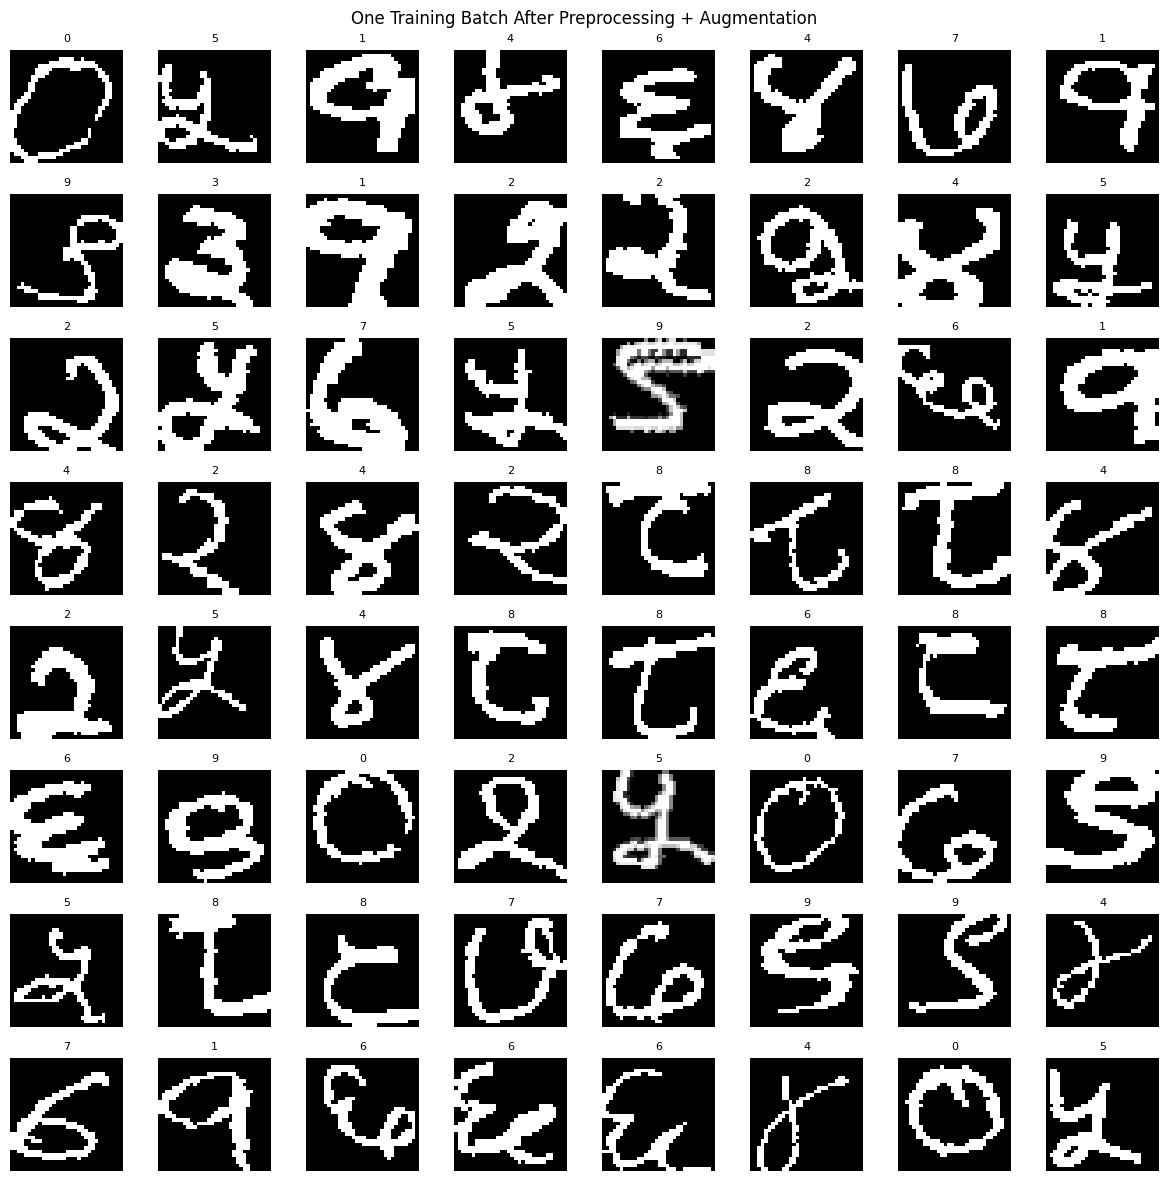

In [6]:
show_one_batch(
    loader=setup.train_loader,
    class_names=setup.class_names,
    mean=setup.mean,
    std=setup.std,
    max_images=64,
)

## Notes
- Preprocessing choices can be toggled in the notebook before building the loaders.
- Augmentation is applied only to the training split.
- Validation data uses preprocessing + normalization only.
- No horizontal/vertical flips are used.